# Integration by Parts

A guided notebook on integrating **products of functions** by reversing the product rule.

This notebook explains:
- the integration-by-parts formula $\int u\,dv = uv - \int v\,du$
- the antiderivative of $\ln(x)$ and of $\log_a(x)$
- the **cyclic** trick: solving for the integral algebraically
- the **LIATE** intuition for choosing $u$ and $dv$

This notebook follows the same style template as the uploaded guidelines, and builds on the earlier integration notebooks.

## 1. Introduction

Finding antiderivatives gets harder as integrands grow more complicated. **Integration by parts** is a technique tailored to integrands that are a **product of two (or more) functions** — for example $x\,e^x$ or $x\sin(x)$.

As its name suggests, the method splits the integrand into *parts*. It is, in essence, the **product rule for derivatives read backwards**.

## 2. Deriving the Formula

Recall the product rule for two functions $u(x)$ and $v(x)$:

$$
(u\cdot v)' = u'\cdot v + u\cdot v'.
$$

Rearranging,

$$
u\cdot v' = (u\cdot v)' - u'\cdot v.
$$

Integrating both sides with respect to $x$:

$$
\int u\cdot v'\,dx = u\cdot v - \int u'\cdot v\,dx.
$$

Since $du = u'(x)\,dx$ and $dv = v'(x)\,dx$, this becomes the main formula:

$$
\boxed{\;\int u\,dv = u\cdot v - \int v\,du\;}
$$

Here $u\,dv$ is the original integrand (including the differential):

- $u$ is usually a function that becomes **simpler after differentiation**;
- $dv$ is $dx$ times a function whose antiderivative $v$ is **easy to find**.

If chosen well, the new integral $\int v\,du$ is easier than the original — sometimes even immediate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x = sp.symbols('x', positive=True)

## 3. First Example: $\displaystyle\int x\,e^x\,dx$

Choose

$$
u = x, \qquad dv = e^x\,dx.
$$

Then find $du$ and $v$:

$$
du = dx, \qquad v = \int e^x\,dx = e^x.
$$

Apply the formula:

$$
\int x\,e^x\,dx = x\,e^x - \int e^x\,dx = x\,e^x - e^x + C.
$$

The new integral $\int e^x\,dx$ was immediate. Therefore:

$$
\boxed{\;\int x\,e^x\,dx = e^x(x - 1) + C\;}
$$

In [2]:
I = sp.integrate(x*sp.exp(x), x)
print("integral of x e^x =", sp.simplify(I), "+ C")
print("factored          =", sp.factor(I), "+ C")

integral of x e^x = (x - 1)*exp(x) + C
factored          = (x - 1)*exp(x) + C


## 4. Integral of Logarithmic Functions

To find $\displaystyle\int \ln(x)\,dx$, rewrite the integrand as a product with $1$:

$$
\int \ln(x)\,dx = \int \ln(x)\cdot 1\,dx
\quad\Longrightarrow\quad
\begin{cases}
u = \ln(x) & \Rightarrow\; du = \dfrac{1}{x}\,dx \\[4pt]
dv = 1\cdot dx & \Rightarrow\; v = x
\end{cases}
$$

Substituting into the formula:

$$
\int \ln(x)\,dx = \ln(x)\cdot x - \int \frac{1}{x}\cdot x\,dx = x\ln(x) - \int 1\,dx = x\ln(x) - x + C.
$$

Therefore:

$$
\boxed{\;\int \ln(x)\,dx = x\big(\ln(x) - 1\big) + C\;}
$$

### Any base

Using the change-of-base property $\log_a(x) = \dfrac{\ln(x)}{\ln(a)}$:

$$
\int \log_a(x)\,dx = \frac{1}{\ln(a)}\int \ln(x)\,dx = x\left(\frac{\ln(x) - 1}{\ln(a)}\right) + C
= x\left(\log_a(x) - \frac{1}{\ln(a)}\right) + C.
$$

In [3]:
print("integral of ln(x)    =", sp.integrate(sp.log(x), x), "+ C")
# log base 2 = ln(x)/ln(2)
I2 = sp.integrate(sp.log(x)/sp.log(2), x)
print("integral of log_2(x) =", sp.simplify(I2), "+ C")

integral of ln(x)    = x*log(x) - x + C
integral of log_2(x) = x*(log(x) - 1)/log(2) + C


## 5. Algebra and Integrals: the Cyclic Trick

Consider

$$
I = \int \sin(x)\cdot 2^x\,dx.
$$

Apply integration by parts with $u = 2^x$, $dv = \sin(x)\,dx$, so $du = \ln(2)\,2^x\,dx$ and $v = -\cos(x)$:

$$
I = -\cos(x)\,2^x + \ln(2)\int \cos(x)\,2^x\,dx.
$$

Apply it **again** to the new integral, with $u = 2^x$, $dv = \cos(x)\,dx$, giving $v = \sin(x)$:

$$
I = -\cos(x)\,2^x + \ln(2)\Big[\sin(x)\,2^x - \ln(2)\int \sin(x)\,2^x\,dx\Big].
$$

The last integral is the **original $I$** again! Substituting and solving algebraically:

$$
I = -\cos(x)\,2^x + \ln(2)\sin(x)\,2^x - \ln^2(2)\,I
$$
$$
\big(\ln^2(2) + 1\big)\,I = -\cos(x)\,2^x + \ln(2)\sin(x)\,2^x.
$$

Therefore (don't forget the constant of integration!):

$$
\boxed{\;\int \sin(x)\,2^x\,dx = \frac{-\cos(x)\,2^x + \ln(2)\sin(x)\,2^x}{\ln^2(2) + 1} + C\;}
$$

When an integrand made of sines, cosines, and exponentials **reappears** after integrating by parts, group it with the original and solve for it.

In [4]:
xr = sp.symbols('x', real=True)
I = sp.integrate(sp.sin(xr)*2**xr, xr)
print("SymPy:", sp.simplify(I), "+ C")

# Compare with our closed form
ours = (-sp.cos(xr)*2**xr + sp.log(2)*sp.sin(xr)*2**xr) / (sp.log(2)**2 + 1)
print("difference (should be 0):", sp.simplify(I - ours))

SymPy: 2**x*(log(2)*sin(x) - cos(x))/(log(2)**2 + 1) + C
difference (should be 0): 0


## 6. Tips for Choosing $u$ and $dv$

The real skill is choosing $u$ and $dv$ well — an intuition built through practice. Two guidelines help newcomers:

**Good candidates for $u$** (they get *simpler* when differentiated): logarithmic, inverse-trigonometric, and polynomial functions.

$$
\frac{d}{dx}\ln(x) = \frac{1}{x}, \quad
\frac{d}{dx}\arctan(x) = \frac{1}{1 + x^2}, \quad
\frac{d}{dx}(x^2 + 5x + 3) = 2x + 5.
$$

(Their antiderivatives, by contrast, are more intricate.)

**Good candidates for $dv$** (neither differentiating nor integrating makes them simpler): exponential and non-inverse trigonometric functions.

$$
\frac{d}{dx}e^x = e^x, \quad \int e^x\,dx = e^x + C, \qquad
\frac{d}{dx}\sin(x) = \cos(x), \quad \int \sin(x)\,dx = -\cos(x) + C.
$$

> A handy mnemonic is **LIATE** — pick $u$ in this priority order: **L**ogarithmic, **I**nverse-trig, **A**lgebraic (polynomial), **T**rigonometric, **E**xponential. Whatever is left becomes $dv$.

### Example: $\displaystyle\int x\sin(x)\,dx$

By LIATE, the algebraic $x$ beats the trigonometric $\sin(x)$, so $u = x$, $dv = \sin(x)\,dx$:

$$
u = x \Rightarrow du = dx, \qquad dv = \sin(x)\,dx \Rightarrow v = -\cos(x),
$$

$$
\int x\sin(x)\,dx = -x\cos(x) + \int \cos(x)\,dx = -x\cos(x) + \sin(x) + C.
$$

In [5]:
print("integral of x sin(x)  =", sp.integrate(xr*sp.sin(xr), xr), "+ C")
print("integral of arctan(x) =", sp.integrate(sp.atan(xr), xr), "+ C")

integral of x sin(x)  = -x*cos(x) + sin(x) + C
integral of arctan(x) = x*atan(x) - log(x**2 + 1)/2 + C


## 7. A Counterexample: the Tips Are Guidelines, Not Rules

Consider

$$
I = \int \frac{x\,e^x}{(x+1)^2}\,dx.
$$

**A poor choice.** Following the polynomial-as-$u$ habit with $u = \dfrac{x}{(x+1)^2}$ and $dv = e^x\,dx$ leads to

$$
I = \frac{x\,e^x}{(x+1)^2} - \int \frac{(x-1)\,e^x}{(x+1)^3}\,dx,
$$

an **even harder** integral.

**A good choice.** Instead take $u = x\,e^x$ and $dv = \dfrac{1}{(x+1)^2}\,dx$, so $du = e^x(x+1)\,dx$ and $v = -\dfrac{1}{x+1}$:

$$
I = -\frac{x\,e^x}{x+1} + \int e^x\,dx = -\frac{x\,e^x}{x+1} + e^x + C = \frac{e^x}{x+1} + C.
$$

**Rule of thumb:** compare the new integral to the original. If it got harder, the choice was probably wrong — there is no shame in going back and choosing again.

In [6]:
I = sp.integrate(x*sp.exp(x)/(x + 1)**2, x)
print("integral of x e^x / (x+1)^2 =", sp.simplify(I), "+ C")

integral of x e^x / (x+1)^2 = exp(x)/(x + 1) + C


## 8. Visual Check

An antiderivative $F$ of $f$ must satisfy $F'(x) = f(x)$ — its slope equals the value of $f$. Let us confirm this for $\int x\,e^x\,dx = e^x(x-1) + C$ by plotting $f(x) = x e^x$ against the slope of $F(x) = e^x(x-1)$.

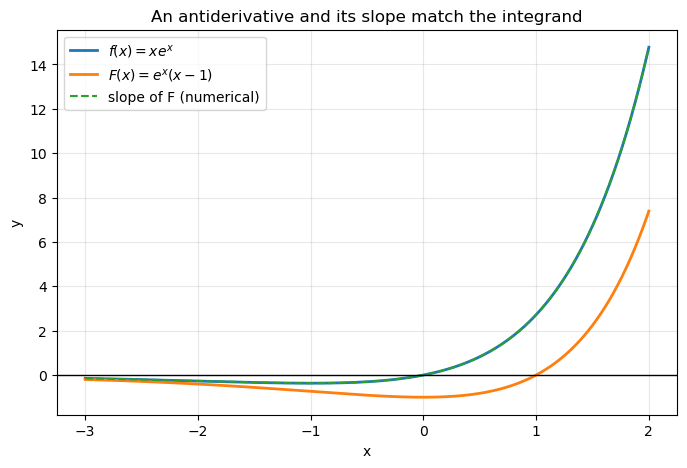

In [7]:
xv = np.linspace(-3, 2, 400)
f_vals = xv*np.exp(xv)
F_vals = np.exp(xv)*(xv - 1)
F_slope = np.gradient(F_vals, xv)   # numerical derivative of F

plt.figure(figsize=(8, 5))
plt.plot(xv, f_vals, label=r"$f(x) = x e^x$", linewidth=2)
plt.plot(xv, F_vals, label=r"$F(x) = e^x(x-1)$", linewidth=2)
plt.plot(xv, F_slope, '--', label="slope of F (numerical)")
plt.title("An antiderivative and its slope match the integrand")
plt.xlabel("x"); plt.ylabel("y")
plt.axhline(0, lw=1, color='black')
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 9. Exercises

### Basic

1. Compute $\displaystyle\int x\,e^{2x}\,dx$.
2. Compute $\displaystyle\int x\cos(x)\,dx$.
3. Compute $\displaystyle\int \log_{10}(x)\,dx$.

### Intermediate

4. Compute $\displaystyle\int x^2 e^x\,dx$ (apply the method twice).
5. Compute $\displaystyle\int \arctan(x)\,dx$.

### Advanced

6. Use the cyclic trick to compute $\displaystyle\int e^x \cos(x)\,dx$.
7. Evaluate the definite integral $\displaystyle\int_1^{e} \ln(x)\,dx$ and interpret the result.

## 10. Solutions / Checks

**1.** $u = x$, $dv = e^{2x}dx$: $\displaystyle\int x e^{2x}dx = \frac{x e^{2x}}{2} - \frac{e^{2x}}{4} + C = \frac{e^{2x}(2x - 1)}{4} + C$.

**2.** $u = x$, $dv = \cos(x)dx$: $\displaystyle\int x\cos(x)dx = x\sin(x) + \cos(x) + C$.

**3.** $\displaystyle\int \log_{10}(x)dx = x\left(\log_{10}(x) - \frac{1}{\ln(10)}\right) + C$.

**4.** Twice: $\displaystyle\int x^2 e^x dx = e^x(x^2 - 2x + 2) + C$.

**5.** $u = \arctan(x)$, $dv = dx$: $\displaystyle\int \arctan(x)dx = x\arctan(x) - \frac{1}{2}\ln(x^2 + 1) + C$.

**6.** Cyclic trick: $\displaystyle\int e^x\cos(x)dx = \frac{e^x(\sin(x) + \cos(x))}{2} + C$.

**7.** $\displaystyle\int_1^e \ln(x)dx = \big[x(\ln x - 1)\big]_1^e = (e\cdot 0) - (1\cdot(-1)) = 1$. The area under $\ln x$ from $1$ to $e$ is exactly $1$.

Run the cell below to verify these symbolically.

In [8]:
x = sp.symbols('x', positive=True)

print("1.", sp.simplify(sp.integrate(x*sp.exp(2*x), x)), "+ C")
print("2.", sp.integrate(x*sp.cos(x), x), "+ C")
print("3.", sp.simplify(sp.integrate(sp.log(x)/sp.log(10), x)), "+ C")
print("4.", sp.simplify(sp.integrate(x**2*sp.exp(x), x)), "+ C")
print("5.", sp.integrate(sp.atan(x), x), "+ C")
print("6.", sp.simplify(sp.integrate(sp.exp(x)*sp.cos(x), x)), "+ C")
print("7.", sp.integrate(sp.log(x), (x, 1, sp.E)))

1. (2*x - 1)*exp(2*x)/4 + C
2. x*sin(x) + cos(x) + C
3. x*(log(x) - 1)/log(10) + C
4. (x**2 - 2*x + 2)*exp(x) + C


5.

 x*atan(x) - log(x**2 + 1)/2 + C
6. sqrt(2)*exp(x)*sin(x + pi/4)/2 + C
7. 1


## 11. Conclusion

In this topic we learned the **integration by parts** method, summarized by

$$
\int u\,dv = u\cdot v - \int v\,du.
$$

We also derived the antiderivative of logarithmic functions:

$$
\int \log_a(x)\,dx = x\left(\log_a(x) - \frac{1}{\ln(a)}\right) + C.
$$

And we saw two key ideas:

- Some integrands **reappear** after integrating by parts; group them with the original and solve algebraically (the *cyclic trick*).
- The **LIATE** guideline helps choose $u$ and $dv$, but it is a guideline, not a rule — always check that the new integral is easier, and re-choose if not.

Key lesson:

$$
\text{integration by parts} = \text{the product rule, reversed.}
$$